In [64]:
# [1] ==============================
# ✅ 실험 상수

SYMBOL = 'AAPL'
START_DATE = '2017-01-01'
END_DATE = '2024-01-01'
SPLIT_DATE = '2022-01-01'

WINDOW_SIZE = 30
SCALER_TYPE = 'minmax'
BATCH_SIZE = 64
EPOCHS = 100
LSTM_UNITS = 64
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
EARLYSTOPPING_PATIENCE = 40

TOP_N_FEATURES = 8
ROLLING_ALLOWANCE = 40

print("✅ 실험 상수 설정 완료")


✅ 실험 상수 설정 완료


In [65]:
# [2] ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta
import yfinance as yf
from ta import add_all_ta_features

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBRegressor

print("✅ 라이브러리 임포트 완료")


✅ 라이브러리 임포트 완료


In [66]:
# [3] ==============================
ticker=yf.Ticker(SYMBOL)
df_raw = ticker.history(start=START_DATE, end=END_DATE, interval='1d').reset_index()
print(df_raw.head())
print(f"✅ 다운로드 완료: {SYMBOL} {START_DATE} ~ {END_DATE}")


                       Date       Open       High        Low      Close  \
0 2017-01-03 00:00:00-05:00  26.746404  26.868819  26.506195  26.827244   
1 2017-01-04 00:00:00-05:00  26.757956  26.910397  26.734859  26.797220   
2 2017-01-05 00:00:00-05:00  26.774128  26.991241  26.748721  26.933498   
3 2017-01-06 00:00:00-05:00  26.972753  27.291494  26.901153  27.233751   
4 2017-01-09 00:00:00-05:00  27.242985  27.584822  27.240676  27.483194   

      Volume  Dividends  Stock Splits  
0  115127600        0.0           0.0  
1   84472400        0.0           0.0  
2   88774400        0.0           0.0  
3  127007600        0.0           0.0  
4  134247600        0.0           0.0  
✅ 다운로드 완료: AAPL 2017-01-01 ~ 2024-01-01


In [67]:
# [4] ==============================
# ✅ add_all_ta_features로 한 번에
df = df_raw.copy()
df = add_all_ta_features(
    df, open="Open", high="High", low="Low", close="Close", volume="Volume", fillna=False
)

# ✅ 타겟 컬럼
# df['Target_Close'] = df['Close'].shift(-1)
HORIZON = 1  # 원하는 Horizon 설정
df['Target_Close'] = df['Close'].shift(-HORIZON)


# ✅ 원본 백업
df_temp = df.copy()

print(f"✅ 기술지표 추가 완료 / 최종 컬럼수: {df.shape[1]}")


✅ 기술지표 추가 완료 / 최종 컬럼수: 95


In [68]:
cols_to_drop = [
    'trend_trix',
    'trend_stc',
    'trend_visual_ichimoku_a',
    'trend_psar_up',
    'trend_psar_down'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"✅ 문제 컬럼 제거 완료. 현재 컬럼수: {df.shape[1]}")

✅ 문제 컬럼 제거 완료. 현재 컬럼수: 90


In [69]:
# ✅ NaN 제거
df = df.dropna().reset_index(drop=True)

In [70]:
# ✅ 원본 백업
df_temp2 = df.copy()

In [71]:
# [6] ==============================
df["Date"] = pd.to_datetime(df["Date"])

train_df = df[df["Date"] < SPLIT_DATE].copy()
test_df = df[df["Date"] >= SPLIT_DATE].copy()

print(f"✅ Train 기간: {train_df['Date'].min()} ~ {train_df['Date'].max()}")
print(f"✅ Test 기간: {test_df['Date'].min()} ~ {test_df['Date'].max()}")


✅ Train 기간: 2017-03-02 00:00:00-05:00 ~ 2021-12-31 00:00:00-05:00
✅ Test 기간: 2022-01-03 00:00:00-05:00 ~ 2023-12-28 00:00:00-05:00


In [72]:
# [7] ==============================
feature_cols_all = df.columns.drop(['Date', 'Target_Close'])

X_train_all = train_df[feature_cols_all]
y_train_all = train_df['Target_Close']

xgb = XGBRegressor(n_estimators=100, max_depth=6)
xgb.fit(X_train_all, y_train_all)

importances = pd.Series(xgb.feature_importances_, index=feature_cols_all)
top_features = importances.sort_values(ascending=False).head(TOP_N_FEATURES).index.tolist()

print("✅ 상위 Feature:")
print(top_features)


✅ 상위 Feature:
['trend_ichimoku_base', 'High', 'volatility_dch', 'volume_vwap', 'Low', 'Close', 'volatility_bbl', 'Open']


In [ ]:
importances.sort_values(ascending=False)

In [73]:
top_features

['trend_ichimoku_base',
 'High',
 'volatility_dch',
 'volume_vwap',
 'Low',
 'Close',
 'volatility_bbl',
 'Open']

In [74]:
df[top_features].corr(method='spearman')

,trend_ichimoku_base,High,volatility_dch,volume_vwap,Low,Close,volatility_bbl,Open
trend_ichimoku_base,1.000000,0.991116,0.997362,0.996517,0.990048,0.990286,0.995340,0.990795
High,0.991116,1.000000,0.991168,0.995453,0.999520,0.999566,0.991726,0.999633
volatility_dch,0.997362,0.991168,1.000000,0.996028,0.989532,0.990073,0.991348,0.990627
volume_vwap,0.996517,0.995453,0.996028,1.000000,0.994908,0.994792,0.997083,0.995485
Low,0.990048,0.999520,0.989532,0.994908,1.000000,0.999584,0.991571,0.999570
Close,0.990286,0.999566,0.990073,0.994792,0.999584,1.000000,0.991258,0.999066
volatility_bbl,0.995340,0.991726,0.991348,0.997083,0.991571,0.991258,1.000000,0.991871
Open,0.990795,0.999633,0.990627,0.995485,0.999570,0.999066,0.991871,1.000000


In [75]:
SELECTED_FEATURES = [
    'Close',
    'trend_ema_fast',
    'volatility_bbm',
    'trend_ichimoku_conv',
    'volume_obv',
    'trend_macd'
]

In [76]:
df[SELECTED_FEATURES].corr()

,Close,trend_ema_fast,volatility_bbm,trend_ichimoku_conv,volume_obv,trend_macd
Close,1.000000,0.998350,0.995992,0.998243,0.937137,0.178110
trend_ema_fast,0.998350,1.000000,0.999257,0.999766,0.933506,0.144731
volatility_bbm,0.995992,0.999257,1.000000,0.998716,0.929672,0.113410
trend_ichimoku_conv,0.998243,0.999766,0.998716,1.000000,0.934338,0.155708
volume_obv,0.937137,0.933506,0.929672,0.934338,1.000000,0.245914
trend_macd,0.178110,0.144731,0.113410,0.155708,0.245914,1.000000


In [77]:
# [8] ==============================
if SCALER_TYPE == 'minmax':
    feature_scaler = MinMaxScaler()
else:
    feature_scaler = RobustScaler()

feature_scaler.fit(train_df[top_features])

train_scaled = feature_scaler.transform(train_df[top_features])
test_scaled = feature_scaler.transform(test_df[top_features])

target_scaler = MinMaxScaler()
target_scaler.fit(train_df[['Target_Close']])

train_target_scaled = target_scaler.transform(train_df[['Target_Close']]).flatten()
test_target_scaled = target_scaler.transform(test_df[['Target_Close']]).flatten()

print("✅ 스케일링 완료")

✅ 스케일링 완료


In [78]:
# # [9] ==============================
# def create_window_data(X, y, window_size):
#     Xs, ys = [], []
#     for i in range(window_size, len(X)):
#         Xs.append(X[i - window_size:i])
#         ys.append(y[i])
#     return np.array(Xs), np.array(ys)

# X_train, y_train = create_window_data(train_scaled, train_target_scaled, WINDOW_SIZE)
# X_test, y_test = create_window_data(test_scaled, test_target_scaled, WINDOW_SIZE)

# print(f"✅ 윈도우 데이터 생성 완료: X_train {X_train.shape}, X_test {X_test.shape}")


In [79]:
# 변경된 윈도우 생성 함수 (호라이즌 설정 가능)
def create_window_data_horizon(X, y, window_size, horizon):
    Xs, ys = [], []
    for i in range(window_size, len(X) - horizon + 1):
        Xs.append(X[i - window_size:i])
        ys.append(y[i + horizon - 1])  # horizon 뒤의 값을 예측
    return np.array(Xs), np.array(ys)

# 적용 예시:
X_train, y_train = create_window_data_horizon(train_scaled, train_target_scaled, WINDOW_SIZE, HORIZON)
X_test, y_test = create_window_data_horizon(test_scaled, test_target_scaled, WINDOW_SIZE, HORIZON)

print(f"✅ 윈도우 데이터 (호라이즌 {HORIZON}) 생성 완료: X_train {X_train.shape}, X_test {X_test.shape}")


✅ 윈도우 데이터 (호라이즌 1) 생성 완료: X_train (1189, 30, 8), X_test (470, 30, 8)


In [80]:
# [10] ==============================
model = Sequential([
    LSTM(LSTM_UNITS, input_shape=(WINDOW_SIZE, X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')

earlystop = EarlyStopping(patience=EARLYSTOPPING_PATIENCE, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[earlystop],
    verbose=2
)

print("✅ 모델 학습 완료")


2025-07-03 10:27:21.556631: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-03 10:27:21.561619: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-03 10:27:21.568704: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Epoch 1/100


2025-07-03 10:27:22.257664: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-03 10:27:22.263741: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-03 10:27:22.266766: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

17/17 - 5s - loss: 0.0342 - val_loss: 0.0055 - 5s/epoch - 291ms/step
Epoch 2/100
17/17 - 0s - loss: 0.0047 - val_loss: 0.0029 - 404ms/epoch - 24ms/step
Epoch 3/100
17/17 - 0s - loss: 0.0027 - val_loss: 0.0046 - 365ms/epoch - 21ms/step
Epoch 4/100
17/17 - 0s - loss: 0.0019 - val_loss: 0.0022 - 362ms/epoch - 21ms/step
Epoch 5/100
17/17 - 0s - loss: 0.0017 - val_loss: 0.0025 - 374ms/epoch - 22ms/step
Epoch 6/100
17/17 - 0s - loss: 0.0017 - val_loss: 0.0017 - 364ms/epoch - 21ms/step
Epoch 7/100
17/17 - 0s - loss: 0.0016 - val_loss: 0.0016 - 392ms/epoch - 23ms/step
Epoch 8/100
17/17 - 0s - loss: 0.0015 - val_loss: 0.0017 - 444ms/epoch - 26ms/step
Epoch 9/100
17/17 - 0s - loss: 0.0015 - val_loss: 0.0017 - 393ms/epoch - 23ms/step
Epoch 10/100
17/17 - 0s - loss: 0.0015 - val_loss: 0.0014 - 379ms/epoch - 22ms/step
Epoch 11/100
17/17 - 0s - loss: 0.0013 - val_loss: 0.0016 - 383ms/epoch - 23ms/step
Epoch 12/100
17/17 - 0s - loss: 0.0011 - val_loss: 0.0018 - 381ms/epoch - 22ms/step
Epoch 13/100
17

 1/38 [..............................] - ETA: 23s

2025-07-03 10:28:06.804482: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-03 10:28:06.808391: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-03 10:28:06.812411: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

15/15 [==============================] - 0s 10ms/step
✅ 예측 및 역변환 완료
✅ RMSE: 4.81
✅ MAE: 3.94
✅ R²: 0.9302


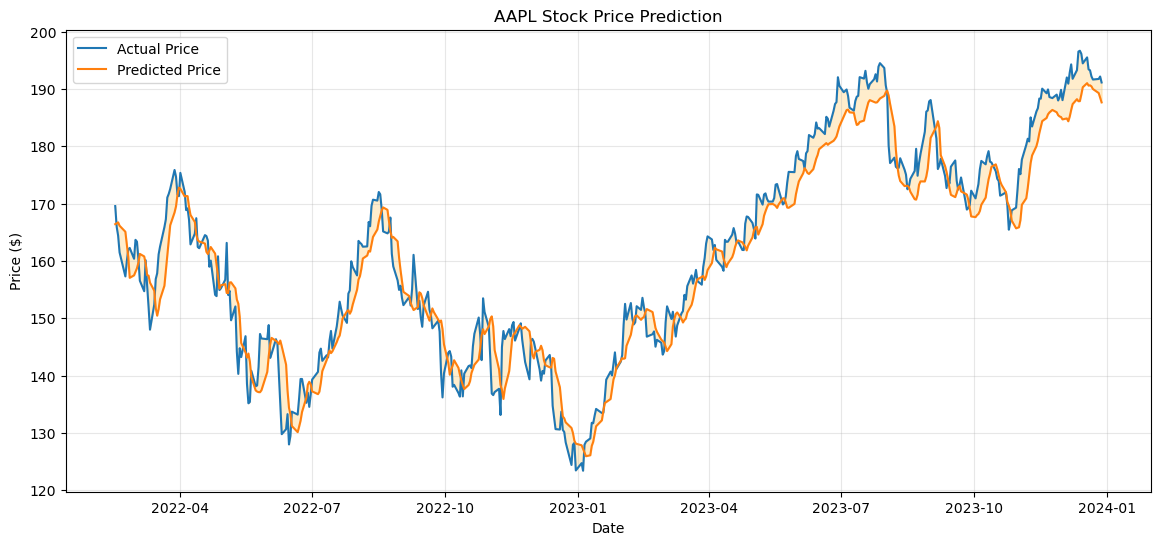

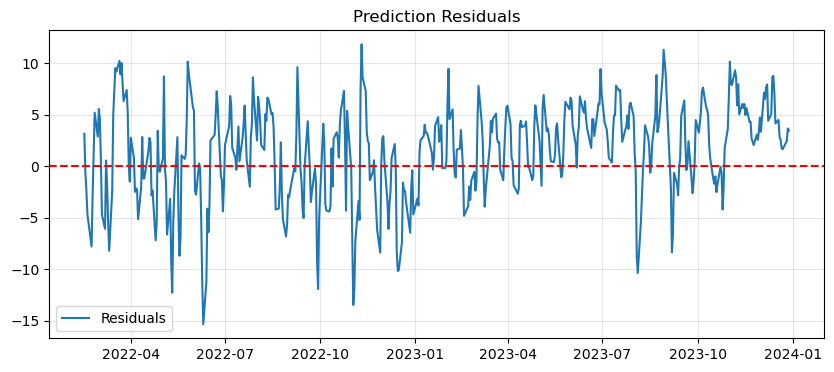

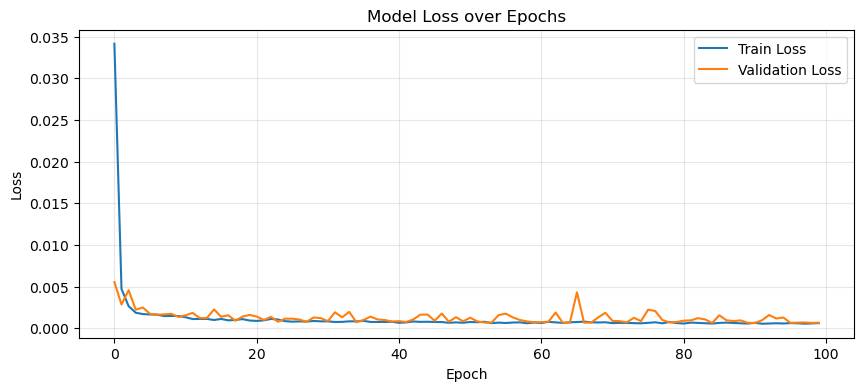

In [81]:
# [11] ==============================
pred_train_scaled = model.predict(X_train).flatten()
pred_test_scaled = model.predict(X_test).flatten()

train_predicted = target_scaler.inverse_transform(pred_train_scaled.reshape(-1,1)).flatten()
test_predicted = target_scaler.inverse_transform(pred_test_scaled.reshape(-1,1)).flatten()

train_actual = target_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()
test_actual = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

print("✅ 예측 및 역변환 완료")

rmse = np.sqrt(mean_squared_error(test_actual, test_predicted))
mae = mean_absolute_error(test_actual, test_predicted)
r2 = r2_score(test_actual, test_predicted)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ MAE: {mae:.2f}")
print(f"✅ R²: {r2:.4f}")

test_dates = test_df["Date"].values[WINDOW_SIZE + HORIZON - 1:]

plt.figure(figsize=(14,6))
plt.plot(test_dates, test_actual, label='Actual Price')
plt.plot(test_dates, test_predicted, label='Predicted Price')
plt.fill_between(test_dates, test_actual, test_predicted, color='orange', alpha=0.2)
plt.title(f'{SYMBOL} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(test_dates, test_actual - test_predicted, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Prediction Residuals')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


윈도우 사이즈 실험

In [90]:
import random
WINDOW_LIST = [3, 10, 30, 60]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
REPEATS = 5

In [ ]:
results = []

for i in range(REPEATS):
    SEED = np.random.randint(100000)
    for window in WINDOW_LIST:
        print(f"\n✅ 실험 - WINDOW_SIZE = {window}")

        # (1) 시드 고정 (매 실험에서 동일 조건 유지)
        random.seed(SEED)
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        # (2) 윈도우 데이터 생성
        X_train, y_train = create_window_data_horizon(train_scaled, train_target_scaled, window, HORIZON)
        X_test, y_test = create_window_data_horizon(test_scaled, test_target_scaled, window, HORIZON)

        # (3) 모델 생성
        model = Sequential([
            LSTM(LSTM_UNITS, input_shape=(window, X_train.shape[2])),
            Dropout(DROPOUT_RATE),
            Dense(1)
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')

        # (4) 학습
        history = model.fit(
            X_train, y_train,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[earlystop],
            verbose=0
        )

        # (5) 예측
        pred_test = model.predict(X_test)
        pred_test_rescaled = target_scaler.inverse_transform(pred_test.reshape(-1, 1)).flatten()
        y_test_rescaled = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


        # (6) 평가 지표
        rmse = np.sqrt(mean_squared_error(y_test_rescaled, pred_test_rescaled))
        mae = mean_absolute_error(y_test_rescaled, pred_test_rescaled)
        r2 = r2_score(y_test_rescaled, pred_test_rescaled)

        results.append({
            'seed': SEED,
            'window': window,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })

# ✅ 결과 출력
# for r in results:
#     print(f"Window: {r['window_size']}, RMSE: {r['rmse']:.2f}, MAE: {r['mae']:.2f}, R2: {r['r2']:.4f}")



✅ 실험 - WINDOW_SIZE = 3


2025-07-03 11:14:03.066931: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-03 11:14:03.070571: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-03 11:14:03.072560: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

 1/16 [>.............................] - ETA: 6s

2025-07-03 11:14:30.567386: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-03 11:14:30.570894: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-03 11:14:30.572640: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

16/16 [==============================] - 0s 5ms/step

✅ 실험 - WINDOW_SIZE = 10


...

15/15 [==============================] - 0s 6ms/step

✅ 실험 - WINDOW_SIZE = 60


2025-07-03 11:22:57.467985: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-03 11:22:57.470789: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-03 11:22:57.472631: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

 1/14 [=>............................] - ETA: 5s

2025-07-03 11:23:30.140599: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-03 11:23:30.144187: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-03 11:23:30.146689: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

14/14 [==============================] - 1s 7ms/step


In [96]:
df_results = pd.DataFrame(results)
summary = df_results.groupby('window').agg(['mean', 'std']).reset_index()
summary

window     seed           rmse                 mae                  r2  \
             mean  std      mean       std      mean       std      mean   
0      3  15795.0  0.0  6.456027  1.766792  5.473194  1.733067  0.860521   
1     10  15795.0  0.0  6.732586  2.038344  5.701345  1.968599  0.848083   
2     30  15795.0  0.0  5.137471  0.694342  4.207701  0.694123  0.919244   
3     60  15795.0  0.0  5.823884  1.486102  4.873220  1.472431  0.898352   

             
        std  
0  0.079273  
1  0.092682  
2  0.023255  
3  0.055739

In [97]:
df_results

,seed,window,rmse,mae,r2
0,15795,3,9.228007,8.210584,0.731142
1,15795,10,7.852061,6.712313,0.807480
2,15795,30,4.867740,3.952147,0.928546
3,15795,60,4.812417,3.888172,0.934030
4,15795,3,4.799159,3.845605,0.927283
5,15795,10,9.720163,8.621519,0.704977
6,15795,30,4.635349,3.727270,0.935205
7,15795,60,6.062622,5.131991,0.895302
8,15795,3,5.619244,4.668367,0.900308
9,15795,10,5.003687,4.106569,0.921821


In [82]:
train_dates = train_df["Date"].values[WINDOW_SIZE + HORIZON - 1:]
test_dates = test_df["Date"].values[WINDOW_SIZE + HORIZON - 1:]
split_date = test_dates[0]
train_residual = train_actual - train_predicted
test_residual = test_actual - test_predicted

/tmp/ipykernel_7297/2683406195.py:42: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7297/2683406195.py:42: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7297/2683406195.py:42: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7297/2683406195.py:42: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7297/2683406195.py:42: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7297/2683406195.py:42: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7297/2683406195.py:42: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.tight_la

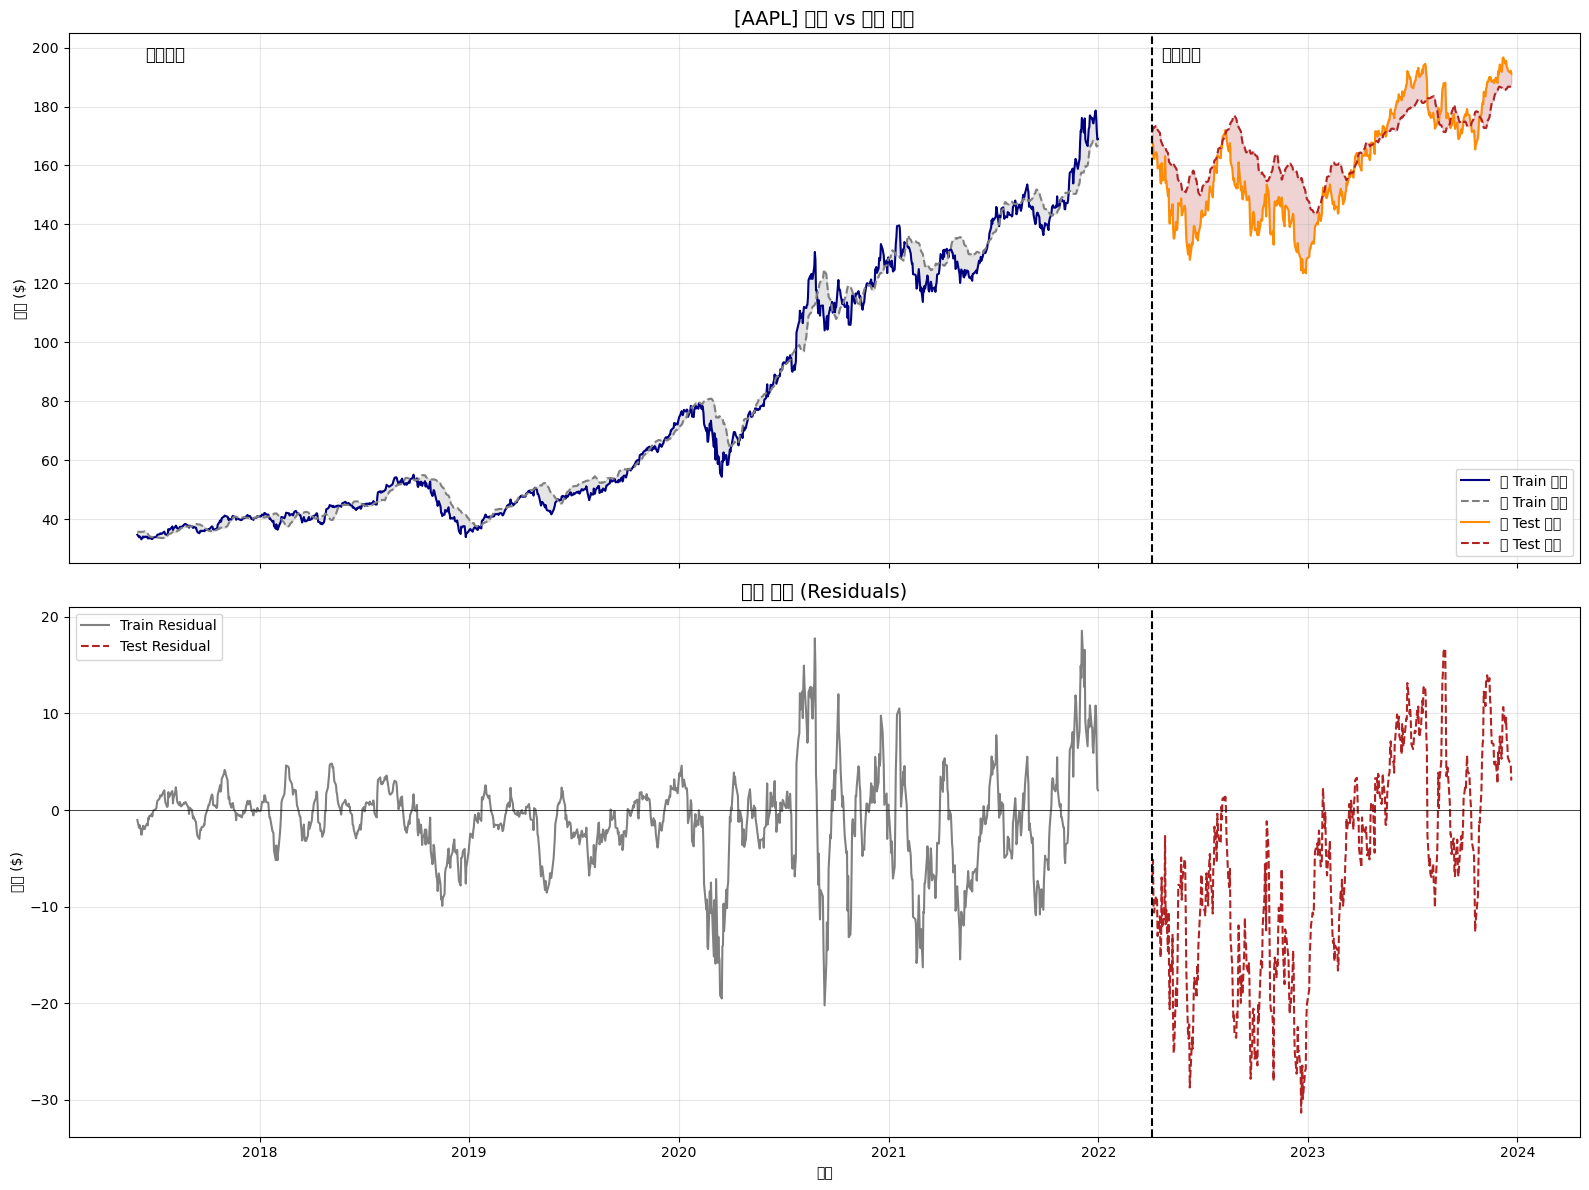

In [25]:
# %%
# ================================
# ✅ [예측 vs 실제 + 잔차 플롯]
# ================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# ===== ① 예측 vs 실제 가격 =====
ax1.plot(train_dates, train_actual, label='🟦 Train 실제', color='navy')
ax1.plot(train_dates, train_predicted, label='⬜ Train 예측', color='gray', linestyle='--')
ax1.fill_between(train_dates, train_actual, train_predicted, color='gray', alpha=0.2)

ax1.plot(test_dates, test_actual, label='🟧 Test 실제', color='darkorange')
ax1.plot(test_dates, test_predicted, label='🟥 Test 예측', color='firebrick', linestyle='--')
ax1.fill_between(test_dates, test_actual, test_predicted, color='firebrick', alpha=0.2)

ax1.axvline(split_date, color='black', linestyle='--', linewidth=1.5)
ax1.set_title(f"[{SYMBOL}] 예측 vs 실제 종가", fontsize=14)
ax1.set_ylabel('종가 ($)')
ax1.legend()
ax1.grid(alpha=0.3)

# Training / Validation Label
ypos = ax1.get_ylim()[0] + 0.95 * (ax1.get_ylim()[1] - ax1.get_ylim()[0])
ax1.text(train_dates[10], ypos, '훈련구간', fontsize=12)
ax1.text(test_dates[10], ypos, '검증구간', fontsize=12)

# ===== ② 잔차 (오차) =====
ax2.plot(train_dates, train_residual, color='gray', label='Train Residual')
ax2.plot(test_dates, test_residual, color='firebrick', linestyle='--', label='Test Residual')

ax2.axvline(split_date, color='black', linestyle='--', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('예측 오차 (Residuals)', fontsize=14)
ax2.set_xlabel('날짜')
ax2.set_ylabel('오차 ($)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


✅ [Backtest] 검증기간 전체 - 매수매도 전략 vs Buy & Hold
✅ 실제 수익률 샘플: [-0.00171821  0.02369368 -0.01894218 -0.0184508   0.00180411]
✅ 예측 기반 포지션 샘플: [ 1. -1. -1.  1.  1.]
✅ 전략 수익률 샘플: [-0.00171821 -0.02369368  0.01894218 -0.0184508   0.00180411]


/tmp/ipykernel_7996/1535765740.py:37: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7996/1535765740.py:37: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7996/1535765740.py:37: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7996/1535765740.py:37: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7996/1535765740.py:37: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7996/1535765740.py:37: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7996/1535765740.py:37: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_

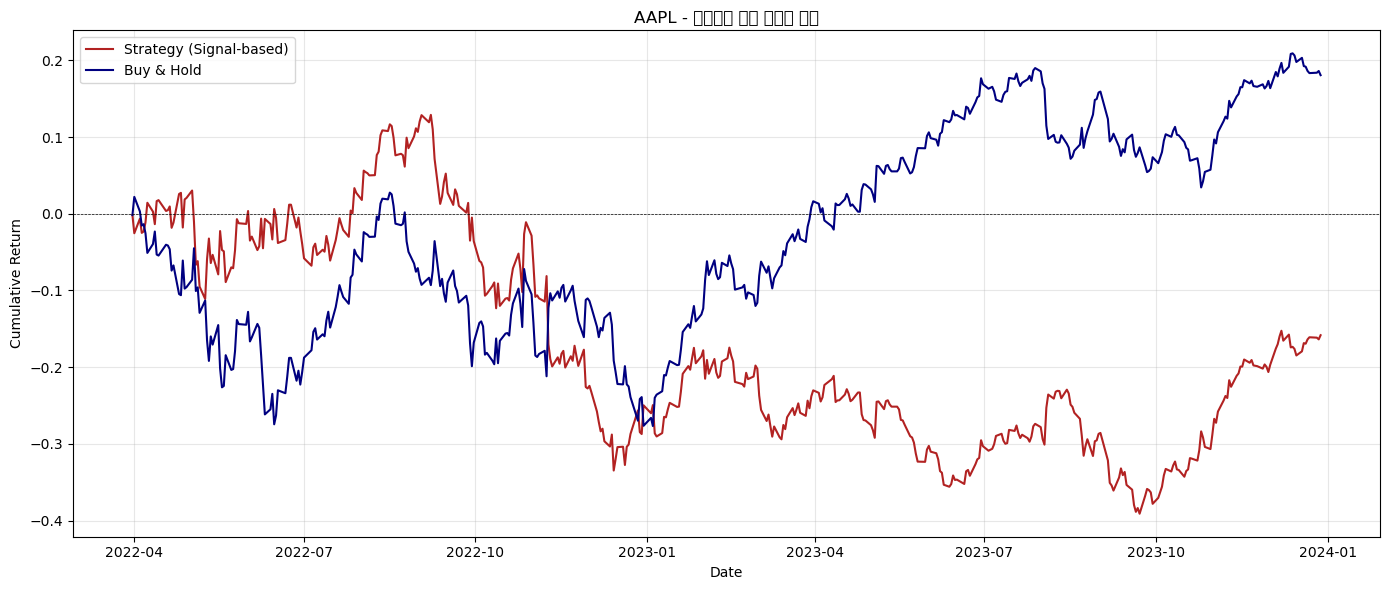

✅ 최종 Strategy Total Return: -0.1583
✅ 최종 Buy & Hold Total Return: 0.1806


In [76]:
# %% [Backtest - 검증기간 전체 매수매도 vs Buy&Hold]
import numpy as np
import matplotlib.pyplot as plt

print("✅ [Backtest] 검증기간 전체 - 매수매도 전략 vs Buy & Hold")

# ✅ ① 실제 수익률 계산 (t+1)
ret_actual_1d = (test_actual[1:] / test_actual[:-1]) - 1
print(f"✅ 실제 수익률 샘플: {ret_actual_1d[:5]}")

# ✅ ② 예측 변화량으로 포지션 결정
pred_diff_1d = test_predicted[1:] - test_predicted[:-1]
position_signal = np.sign(pred_diff_1d)
print(f"✅ 예측 기반 포지션 샘플: {position_signal[:5]}")

# ✅ ③ 전략 수익률 = 포지션 * 실제 수익률
ret_strategy_1d = position_signal * ret_actual_1d
print(f"✅ 전략 수익률 샘플: {ret_strategy_1d[:5]}")

# ✅ ④ 누적 수익률 곡선
cum_strategy_return = np.cumsum(ret_strategy_1d)
cum_buyhold_return = np.cumsum(ret_actual_1d)

# ✅ ⑤ 날짜축 (1칸 맞춤)
backtest_dates = test_dates[1:]

# ✅ ⑥ 시각화 - 누적 수익률 비교
plt.figure(figsize=(14, 6))
plt.plot(backtest_dates, cum_strategy_return, label='Strategy (Signal-based)', color='firebrick')
plt.plot(backtest_dates, cum_buyhold_return, label='Buy & Hold', color='navy')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title(f'{SYMBOL} - 검증기간 누적 수익률 비교')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ✅ ⑦ 최종 결과 출력
total_strat_return = cum_strategy_return[-1]
total_bh_return = cum_buyhold_return[-1]
print(f"✅ 최종 Strategy Total Return: {total_strat_return:.4f}")
print(f"✅ 최종 Buy & Hold Total Return: {total_bh_return:.4f}")



✅ 훈련 데이터 랜덤 윈도우 커버 시작
✅ 샘플 수: 75
✅ 평균 Strategy Return: 0.0022
✅ 평균 Buy&Hold Return: 0.0229
✅ 평균 차이 (Strategy - Buy&Hold): -0.0207


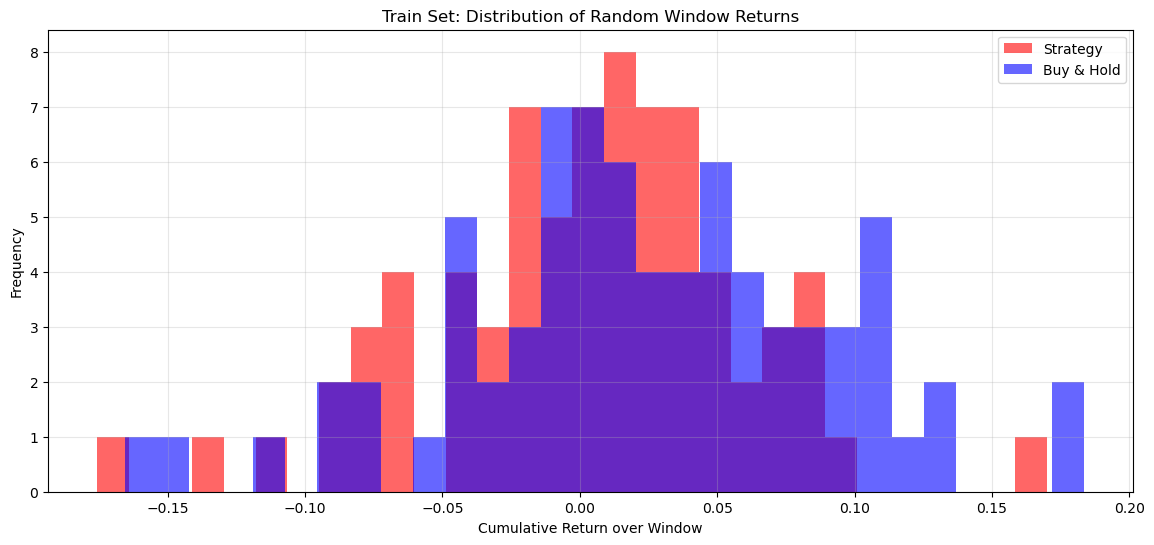

In [74]:
# =========================
# ✅ 훈련 기간만 랜덤 윈도우 백테스트
# =========================

MIN_WINDOW = 3
MAX_WINDOW = 30

print("\n✅ 훈련 데이터 랜덤 윈도우 커버 시작")
all_actual = train_actual
all_predicted = train_predicted
all_dates = train_dates

total_len = len(all_actual)

strategy_returns = []
buyhold_returns = []
window_lengths = []
dates_midpoints = []

start = 0
while start < total_len - MIN_WINDOW:
    window_length = np.random.randint(MIN_WINDOW, MAX_WINDOW + 1)
    if start + window_length >= total_len:
        break

    end = start + window_length

    actual_window = all_actual[start:end+1]
    predicted_window = all_predicted[start:end+1]

    actual_return = (actual_window[1:] / actual_window[:-1]) - 1
    pred_diff = predicted_window[1:] - predicted_window[:-1]
    pred_position = np.sign(pred_diff)
    strat_return = pred_position * actual_return

    strategy_returns.append(np.sum(strat_return))
    buyhold_returns.append(np.sum(actual_return))
    window_lengths.append(window_length)
    dates_midpoints.append(all_dates[start + window_length // 2])

    start = end

# ✅ 요약
print(f"✅ 샘플 수: {len(strategy_returns)}")
print(f"✅ 평균 Strategy Return: {np.mean(strategy_returns):.4f}")
print(f"✅ 평균 Buy&Hold Return: {np.mean(buyhold_returns):.4f}")
print(f"✅ 평균 차이 (Strategy - Buy&Hold): {np.mean(np.array(strategy_returns)-np.array(buyhold_returns)):.4f}")

# ✅ 히스토그램
plt.figure(figsize=(14,6))
plt.hist(strategy_returns, bins=30, alpha=0.6, label='Strategy', color='red')
plt.hist(buyhold_returns, bins=30, alpha=0.6, label='Buy & Hold', color='blue')
plt.title('Train Set: Distribution of Random Window Returns')
plt.xlabel('Cumulative Return over Window')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



✅ 검증 데이터 랜덤 윈도우 커버 시작
✅ 샘플 수: 24
✅ 평균 Strategy Return: -0.0067
✅ 평균 Buy&Hold Return: 0.0076
✅ 평균 차이 (Strategy - Buy&Hold): -0.0143


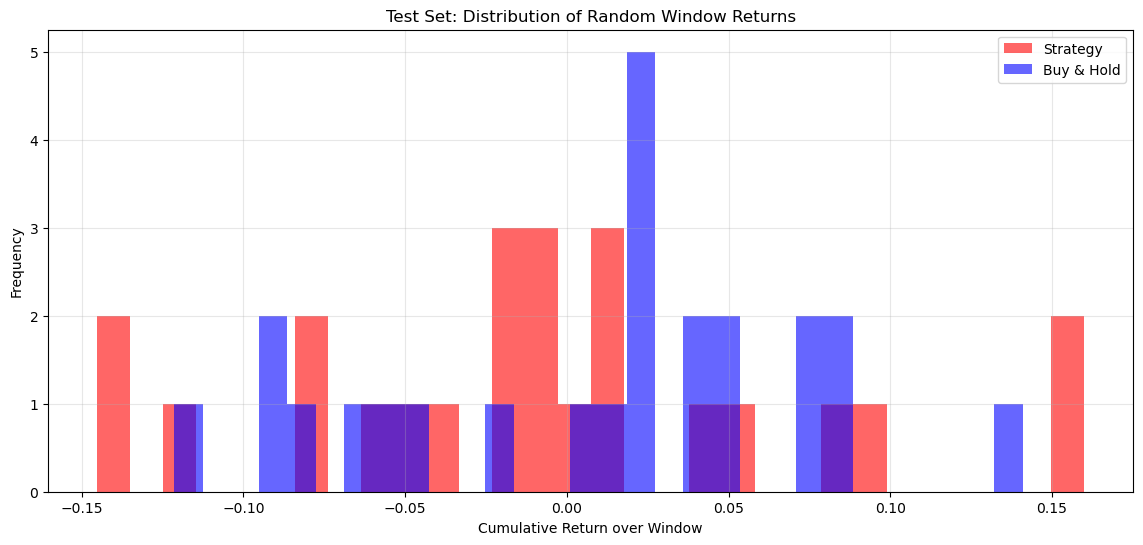

In [73]:
# =========================
# ✅ 검증 기간만 랜덤 윈도우 백테스트
# =========================

print("\n✅ 검증 데이터 랜덤 윈도우 커버 시작")
all_actual = test_actual
all_predicted = test_predicted
all_dates = test_dates

total_len = len(all_actual)

strategy_returns = []
buyhold_returns = []
window_lengths = []
dates_midpoints = []

start = 0
while start < total_len - MIN_WINDOW:
    window_length = np.random.randint(MIN_WINDOW, MAX_WINDOW + 1)
    if start + window_length >= total_len:
        break

    end = start + window_length

    actual_window = all_actual[start:end+1]
    predicted_window = all_predicted[start:end+1]

    actual_return = (actual_window[1:] / actual_window[:-1]) - 1
    pred_diff = predicted_window[1:] - predicted_window[:-1]
    pred_position = np.sign(pred_diff)
    strat_return = pred_position * actual_return

    strategy_returns.append(np.sum(strat_return))
    buyhold_returns.append(np.sum(actual_return))
    window_lengths.append(window_length)
    dates_midpoints.append(all_dates[start + window_length // 2])

    start = end

# ✅ 요약
print(f"✅ 샘플 수: {len(strategy_returns)}")
print(f"✅ 평균 Strategy Return: {np.mean(strategy_returns):.4f}")
print(f"✅ 평균 Buy&Hold Return: {np.mean(buyhold_returns):.4f}")
print(f"✅ 평균 차이 (Strategy - Buy&Hold): {np.mean(np.array(strategy_returns)-np.array(buyhold_returns)):.4f}")

# ✅ 히스토그램
plt.figure(figsize=(14,6))
plt.hist(strategy_returns, bins=30, alpha=0.6, label='Strategy', color='red')
plt.hist(buyhold_returns, bins=30, alpha=0.6, label='Buy & Hold', color='blue')
plt.title('Test Set: Distribution of Random Window Returns')
plt.xlabel('Cumulative Return over Window')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
